In [1]:
from common.paths import get_data_raw_dpath
from common.logger import JUPYTER_LOGGER as logger

import catboost as cb
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import optuna

from matplotlib import pyplot as plt
import seaborn as sns

from typing import *

In [2]:
data_fpath = get_data_raw_dpath() / 'features_with_judge_scores.csv'
df = pd.read_csv(data_fpath)
features_cols = [col for col in df.columns if "feature_" in col]
logger.info(f'Features columns len: {len(features_cols)}')
df.head()

2026-04-05 17:38:55,055 - jupyter-notebooks - INFO - [JUPYTER 📓] Features columns len: 1613


,sample_id,query,correct_answer,model_answer,temperature,hallucination_score,is_hallucination,feature_0,feature_1,feature_2,...,feature_1605,feature_1606,feature_1607,feature_1608,feature_1609,feature_1610,feature_1611,feature_1612,judge_prompt,judge_score
0,0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,1.049065,41.666667,1,-2.184582,-16.949598,-0.000303,...,0.028273,0.019163,0.029646,0.015739,0.073697,0.044748,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
1,1,"Где родился создатель музыки к фильму ""Крадено...",Каламата,Создателем музыки к фильму «Краденое небо» явл...,1.049065,37.500000,1,-2.548452,-17.273001,-0.000017,...,0.027378,0.014426,0.033654,0.019120,0.075012,0.035969,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
2,2,"Именно ему мы так верили, ""как, может быть, не...",Жириновскому,Эта фраза — цитата из романа Михаила Булгакова...,1.049065,50.000000,1,-2.475740,-16.976189,-0.000039,...,0.038252,0.016981,0.041029,0.022800,0.096321,0.038822,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
3,3,В этой знаменитой российской иерархии было 14 ...,"В ""Табели о рангах""","Вероятно, вы имеете в виду «Иерархию» — знамен...",1.049065,47.368421,1,-0.628662,-3.925333,-0.000001,...,0.068875,0.014358,0.075975,0.026233,0.160563,0.027780,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
4,4,"Согласно Большому толковому словарю, это — ""не...","Стопка. Зачет: Стопарь, стопарик",Это слово - *штоф*. \r\n\r\nШтоф — это небольш...,1.049065,40.625000,1,-2.889339,-17.423979,-0.000020,...,0.047839,0.027707,0.053740,0.039204,0.116196,0.058728,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True


In [3]:
features_cols_start_idx = df.columns.get_loc(features_cols[0])
features_cols_end_idx = df.columns.get_loc(features_cols[-1])
logger.info(f'Features columns index range: {features_cols_start_idx}–{features_cols_end_idx}')

features_cols_map = {
    (0, 11): "uncertainty",
    (12, 35): "internal_scalars",
    (36, 1571): "probe_vec",
    (1572, 1595): "attention_entropy",
    (1596, 1602): "entropy_drops",
    (1603, 1612): "moe_routing",
}

uncertainty_map = [
    "mean_log_prob",        # 0
    "min_log_prob",         # 1
    "max_log_prob",         # 2
    "std_log_prob",         # 3
    "mean_entropy",         # 4
    "min_entropy",          # 5
    "max_entropy",          # 6
    "std_entropy",          # 7
    "n_answer_tokens",      # 8
    "first_token_log_prob", # 9
    "mean_top1_prob",       # 10
    "mean_top5_prob_sum",   # 11
]

PROBE_LAYERS = [0, 4, 8, 12, 16, 20, 24, 25]

internal_scalars_map = [
    f"layer_{l}_{s}"
    for l in PROBE_LAYERS
    for s in ["prompt_last_token_norm", "answer_hidden_norm_mean", "logit_lens_entropy"]
]
# layer_0_prompt_last_token_norm, layer_0_answer_hidden_norm_mean, layer_0_logit_lens_entropy,
# layer_4_prompt_last_token_norm, ...

probe_vec_map = [f"probe_vec_{i}" for i in range(1536)]  # 36–1571

attention_entropy_map = [
    f"attn_layer_{l}_{s}"
    for l in PROBE_LAYERS
    for s in ["entropy_mean", "entropy_max", "entropy_std"]
]
# attn_layer_0_entropy_mean, attn_layer_0_entropy_max, attn_layer_0_entropy_std,
# attn_layer_4_entropy_mean, ...

entropy_drops_map = [
    f"entropy_drop_{PROBE_LAYERS[i]}_to_{PROBE_LAYERS[i+1]}"
    for i in range(len(PROBE_LAYERS) - 1)
]
# entropy_drop_0_to_4, entropy_drop_4_to_8, ..., entropy_drop_24_to_25

moe_routing_map = [
    "moe_mean_top_prob_mean",
    "moe_mean_top_prob_std",
    "moe_std_top_prob_mean",
    "moe_std_top_prob_std",
    "moe_mean_entropy_mean",
    "moe_mean_entropy_std",
    "moe_std_entropy_mean",
    "moe_std_entropy_std",
    "moe_active_ratio_mean",
    "moe_active_ratio_std",
]

# Полный маппинг feature_0..feature_1612 → имя
all_feature_names = (
    uncertainty_map
    + internal_scalars_map
    + probe_vec_map
    + attention_entropy_map
    + entropy_drops_map
    + moe_routing_map
)

assert len(features_cols) == len(all_feature_names)

rename_map = dict(zip(features_cols, all_feature_names))
df.rename(columns=rename_map, inplace=True)

df.head()

2026-04-05 17:38:55,452 - jupyter-notebooks - INFO - [JUPYTER 📓] Features columns index range: 7–1619


,sample_id,query,correct_answer,model_answer,temperature,hallucination_score,is_hallucination,mean_log_prob,min_log_prob,max_log_prob,...,moe_std_top_prob_mean,moe_std_top_prob_std,moe_mean_entropy_mean,moe_mean_entropy_std,moe_std_entropy_mean,moe_std_entropy_std,moe_active_ratio_mean,moe_active_ratio_std,judge_prompt,judge_score
0,0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,1.049065,41.666667,1,-2.184582,-16.949598,-0.000303,...,0.028273,0.019163,0.029646,0.015739,0.073697,0.044748,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
1,1,"Где родился создатель музыки к фильму ""Крадено...",Каламата,Создателем музыки к фильму «Краденое небо» явл...,1.049065,37.500000,1,-2.548452,-17.273001,-0.000017,...,0.027378,0.014426,0.033654,0.019120,0.075012,0.035969,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
2,2,"Именно ему мы так верили, ""как, может быть, не...",Жириновскому,Эта фраза — цитата из романа Михаила Булгакова...,1.049065,50.000000,1,-2.475740,-16.976189,-0.000039,...,0.038252,0.016981,0.041029,0.022800,0.096321,0.038822,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
3,3,В этой знаменитой российской иерархии было 14 ...,"В ""Табели о рангах""","Вероятно, вы имеете в виду «Иерархию» — знамен...",1.049065,47.368421,1,-0.628662,-3.925333,-0.000001,...,0.068875,0.014358,0.075975,0.026233,0.160563,0.027780,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True
4,4,"Согласно Большому толковому словарю, это — ""не...","Стопка. Зачет: Стопарь, стопарик",Это слово - *штоф*. \r\n\r\nШтоф — это небольш...,1.049065,40.625000,1,-2.889339,-17.423979,-0.000020,...,0.047839,0.027707,0.053740,0.039204,0.116196,0.058728,0.5,0.0,"\r\nТы — судья, оценивающий точность ответа мо...",True


In [4]:
# cfg

# preprocessing
pca_n_components: Optional[int] = 32
scaling: bool = False
under_sampling: bool = False
oversampling: bool = True

# fixed class weight из исходного train-распределения (до оверсемплинга)
fixed_pos_weight: float | None = None

# optuna objectives
X, y, X_val, y_val, X_test, y_test, X_train, y_train = None, None, None, None, None, None, None, None
def objective_lgbm(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "verbosity": -1,
        "random_state": 42,
    }
    if fixed_pos_weight is not None:
        params["scale_pos_weight"] = fixed_pos_weight

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if oversampling and not under_sampling:
            from imblearn.over_sampling import SMOTE

            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
            X_train = pd.DataFrame(X_resampled, columns=X_train.columns)
            y_train = pd.Series(y_resampled, name=y_train.name)

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train, eval_set=(X_val, y_val))
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, preds))

    return np.mean(scores)

def objective_catboost(trial):
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-4, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "early_stopping_rounds": 50,
        "verbose": False,
        "random_seed": 42,
    }
    if fixed_pos_weight is not None:
        params["scale_pos_weight"] = fixed_pos_weight

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if oversampling and not under_sampling:
            from imblearn.over_sampling import SMOTE

            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
            X_train = pd.DataFrame(X_resampled, columns=X_train.columns)
            y_train = pd.Series(y_resampled, name=y_train.name)

        model = cb.CatBoostClassifier(**params)
        model.fit(X_train, y_train, eval_set=(X_val, y_val))
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, preds))

    return np.mean(scores)

def objective_xgboost(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "verbosity": 0,
        "random_state": 42,
    }
    if fixed_pos_weight is not None:
        params["scale_pos_weight"] = fixed_pos_weight

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if oversampling and not under_sampling:
            from imblearn.over_sampling import SMOTE

            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
            X_train = pd.DataFrame(X_resampled, columns=X_train.columns)
            y_train = pd.Series(y_resampled, name=y_train.name)

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, preds))

    return np.mean(scores)

C:\Users\User\AppData\Local\Temp\ipykernel_7380\3995749295.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  num_cols = df.columns.difference(df.select_dtypes(include=['object']).columns).difference(["sample_id"])
C:\Users\User\AppData\Local\Temp\ipykernel_7380\3995749295.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.

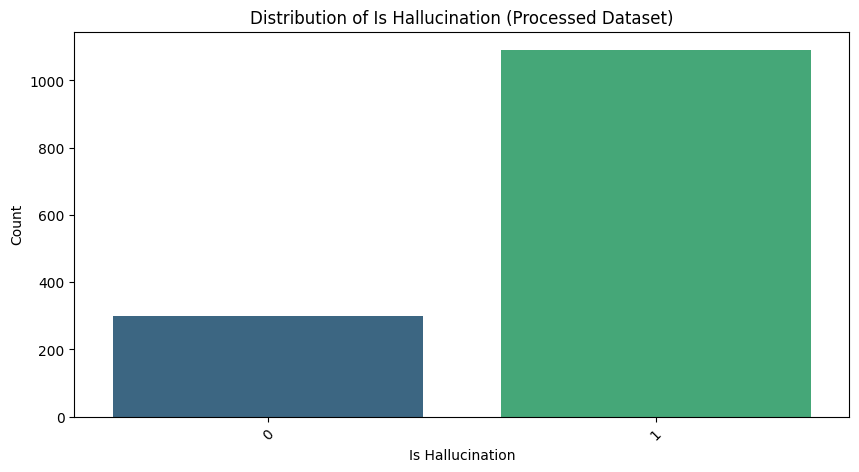

In [5]:
# Preprocessing

num_cols = df.columns.difference(df.select_dtypes(include=['object']).columns).difference(["sample_id"])
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

if pca_n_components is not None:
    pca = PCA(n_components=pca_n_components, random_state=42)

    # only probe_vec features
    probe_vec_features = df[probe_vec_map].values
    pca_features = pca.fit_transform(probe_vec_features)
    pca_feature_names = [f"pca_probe_vec_{i}" for i in range(pca_n_components)]
    df_pca = pd.DataFrame(pca_features, columns=pca_feature_names)

    preprocessed_df = pd.concat([df.drop(columns=probe_vec_map), df_pca], axis=1)
else:
    preprocessed_df = df.copy()

if scaling:
    from sklearn.preprocessing import StandardScaler

    train_cols_for_scaling = preprocessed_df.columns.difference(
        preprocessed_df.select_dtypes(include=['object']).columns
    ).difference(['is_hallucination', 'sample_id'])
    scalers = {
        col_name: StandardScaler() for col_name in train_cols_for_scaling
    }
    for col_name in train_cols_for_scaling:
        preprocessed_df[col_name] = scalers[col_name].fit_transform(preprocessed_df[[col_name]]) # noqa

if under_sampling:
    from imblearn.under_sampling import RandomUnderSampler

    rus = RandomUnderSampler(random_state=42)
    feature_part = preprocessed_df.drop(columns=['query', 'judge_score', 'is_hallucination'])
    X_resampled, y_resampled = rus.fit_resample(feature_part, preprocessed_df['is_hallucination'])
    preprocessed_df = pd.DataFrame(X_resampled, columns=feature_part.columns)
    preprocessed_df['is_hallucination'] = y_resampled

    preprocessed_df['query'] = df.loc[preprocessed_df.index, 'query'].values
    preprocessed_df['judge_score'] = df.loc[preprocessed_df.index, 'judge_score'].values

train_cols = preprocessed_df.columns.difference(
    preprocessed_df.select_dtypes(include=['object']).columns).difference(
    ['sample_id', 'hallucination_score', 'judge_score']
)


df_processed_hist = preprocessed_df['is_hallucination'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=df_processed_hist.index, y=df_processed_hist.values, palette='viridis')
plt.title('Distribution of Is Hallucination (Processed Dataset)')
plt.xlabel('Is Hallucination')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [6]:
preprocessed_df[train_cols].columns.to_list()

['attn_layer_0_entropy_max',
 'attn_layer_0_entropy_mean',
 'attn_layer_0_entropy_std',
 'attn_layer_12_entropy_max',
 'attn_layer_12_entropy_mean',
 'attn_layer_12_entropy_std',
 'attn_layer_16_entropy_max',
 'attn_layer_16_entropy_mean',
 'attn_layer_16_entropy_std',
 'attn_layer_20_entropy_max',
 'attn_layer_20_entropy_mean',
 'attn_layer_20_entropy_std',
 'attn_layer_24_entropy_max',
 'attn_layer_24_entropy_mean',
 'attn_layer_24_entropy_std',
 'attn_layer_25_entropy_max',
 'attn_layer_25_entropy_mean',
 'attn_layer_25_entropy_std',
 'attn_layer_4_entropy_max',
 'attn_layer_4_entropy_mean',
 'attn_layer_4_entropy_std',
 'attn_layer_8_entropy_max',
 'attn_layer_8_entropy_mean',
 'attn_layer_8_entropy_std',
 'entropy_drop_0_to_4',
 'entropy_drop_12_to_16',
 'entropy_drop_16_to_20',
 'entropy_drop_20_to_24',
 'entropy_drop_24_to_25',
 'entropy_drop_4_to_8',
 'entropy_drop_8_to_12',
 'first_token_log_prob',
 'is_hallucination',
 'layer_0_answer_hidden_norm_mean',
 'layer_0_logit_lens_e

In [7]:
X = preprocessed_df[train_cols].drop(columns=['is_hallucination'])
y = preprocessed_df['is_hallucination']

X_train_base, X_temp, y_train_base, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

train_class_counts = y_train_base.value_counts().to_dict()
positive_count: int = int(train_class_counts.get(1, 0))
negative_count: int = int(train_class_counts.get(0, 0))
if positive_count > 0:
    fixed_pos_weight = float(negative_count / positive_count)
else:
    fixed_pos_weight = 1.0
logger.info(
    f"Fixed pos_weight from base train distribution: {fixed_pos_weight:.4f} "
    f"(neg={negative_count}, pos={positive_count})"
)

X_train = X_train_base.copy()
y_train = y_train_base.copy()
if oversampling and not under_sampling:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_base, y_train_base)
    X_train = pd.DataFrame(X_train_resampled, columns=X_train_base.columns)
    y_train = pd.Series(y_train_resampled, name=y_train_base.name)

# Optuna CV обучается на train-части; oversampling для каждой фолд-обучающей части внутри objective.
X = X_train_base.reset_index(drop=True)
y = y_train_base.reset_index(drop=True)

logger.info(f'Train shape (base): {X_train_base.shape}, Train shape (fit): {X_train.shape}')
logger.info(f'Val shape: {X_val.shape}, Test shape: {X_test.shape}')

2026-04-05 17:39:01,245 - jupyter-notebooks - INFO - [JUPYTER 📓] Fixed pos_weight from base train distribution: 0.2752 (neg=210, pos=763)
2026-04-05 17:39:04,536 - jupyter-notebooks - INFO - [JUPYTER 📓] Train shape (base): (973, 110), Train shape (fit): (1526, 110)
2026-04-05 17:39:04,538 - jupyter-notebooks - INFO - [JUPYTER 📓] Val shape: (209, 110), Test shape: (209, 110)


In [8]:
# Optuna tuning

logger.info('Starting LightGBM tuning...')
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=5)

logger.info('Starting CatBoost tuning...')
study_catboost = optuna.create_study(direction="maximize")
study_catboost.optimize(objective_catboost, n_trials=5)

logger.info('Starting XGBoost tuning...')
study_xgboost = optuna.create_study(direction="maximize")
study_xgboost.optimize(objective_xgboost, n_trials=5)

2026-04-05 17:39:04,647 - jupyter-notebooks - INFO - [JUPYTER 📓] Starting LightGBM tuning...
[I 2026-04-05 17:39:04,647] A new study created in memory with name: no-name-3a12515e-60dc-41a4-9241-db4577324f81
[I 2026-04-05 17:39:08,606] Trial 0 finished with value: 0.8645678985449742 and parameters: {'learning_rate': 0.043734602198470154, 'max_depth': 6, 'num_leaves': 19, 'subsample': 0.5938317423278989, 'colsample_bytree': 0.8412797479804515, 'min_child_samples': 58, 'reg_alpha': 0.002518462718052878, 'reg_lambda': 0.000949808196724292}. Best is trial 0 with value: 0.8645678985449742.
[I 2026-04-05 17:39:11,023] Trial 1 finished with value: 0.8669604963585558 and parameters: {'learning_rate': 0.04456165730523036, 'max_depth': 4, 'num_leaves': 46, 'subsample': 0.5358216629680265, 'colsample_bytree': 0.5085867177967347, 'min_child_samples': 53, 'reg_alpha': 0.5801496616203081, 'reg_lambda': 4.6796554212466095}. Best is trial 1 with value: 0.8669604963585558.
[I 2026-04-05 17:39:13,167] Tr

In [9]:
logger.info(f'Best LightGBM params: {study_lgbm.best_params}, Best score: {study_lgbm.best_value}')
logger.info(f'Best CatBoost params: {study_catboost.best_params}, Best score: {study_catboost.best_value}')
logger.info(f'Best XGBoost params: {study_xgboost.best_params}, Best score: {study_xgboost.best_value}')

2026-04-05 17:40:10,810 - jupyter-notebooks - INFO - [JUPYTER 📓] Best LightGBM params: {'learning_rate': 0.04456165730523036, 'max_depth': 4, 'num_leaves': 46, 'subsample': 0.5358216629680265, 'colsample_bytree': 0.5085867177967347, 'min_child_samples': 53, 'reg_alpha': 0.5801496616203081, 'reg_lambda': 4.6796554212466095}, Best score: 0.8669604963585558
2026-04-05 17:40:10,810 - jupyter-notebooks - INFO - [JUPYTER 📓] Best CatBoost params: {'learning_rate': 0.023591853497199108, 'depth': 7, 'l2_leaf_reg': 3.9731607316290023, 'subsample': 0.9503732249969208, 'colsample_bylevel': 0.9513123967061387, 'min_data_in_leaf': 36}, Best score: 0.8522443403321501
2026-04-05 17:40:10,810 - jupyter-notebooks - INFO - [JUPYTER 📓] Best XGBoost params: {'learning_rate': 0.026964231361277836, 'max_depth': 7, 'subsample': 0.567149675991689, 'colsample_bytree': 0.7363807625490111, 'min_child_weight': 35, 'reg_alpha': 0.01505970615376081, 'reg_lambda': 0.006980254601156495}, Best score: 0.8710801339441316

In [ ]:
best_lgbm_params = dict(study_lgbm.best_params)
best_catboost_params = dict(study_catboost.best_params)
best_xgboost_params = dict(study_xgboost.best_params)
if fixed_pos_weight is not None:
    best_lgbm_params["scale_pos_weight"] = fixed_pos_weight
    best_catboost_params["scale_pos_weight"] = fixed_pos_weight
    best_xgboost_params["scale_pos_weight"] = fixed_pos_weight

model_lgbm = lgb.LGBMClassifier(**best_lgbm_params)
model_lgbm.fit(X_train, y_train, eval_set=(X_val, y_val))
preds_lgbm = model_lgbm.predict_proba(X_val)[:, 1]

model_catboost = cb.CatBoostClassifier(**best_catboost_params)
model_catboost.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
preds_catboost = model_catboost.predict_proba(X_val)[:, 1]

model_xgboost = xgb.XGBClassifier(**best_xgboost_params)
model_xgboost.fit(X_train, y_train, eval_set=[(X_val, y_val)])
preds_xgboost = model_xgboost.predict_proba(X_val)[:, 1]

# ── стекинг ──────────────────────────────────────────────────────────────────

# OOF на X_train для мета-модели
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np

N_SPLITS = 5
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_lgbm     = np.zeros(len(X_train))
oof_catboost = np.zeros(len(X_train))
oof_xgboost  = np.zeros(len(X_train))

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # lgbm
    m = lgb.LGBMClassifier(**best_lgbm_params)
    m.fit(X_tr, y_tr, eval_set=(X_cv, y_cv))
    oof_lgbm[val_idx] = m.predict_proba(X_cv)[:, 1]

    # catboost
    m = cb.CatBoostClassifier(**best_catboost_params)
    m.fit(X_tr, y_tr, eval_set=(X_cv, y_cv), early_stopping_rounds=50, verbose=False)
    oof_catboost[val_idx] = m.predict_proba(X_cv)[:, 1]

    # xgboost
    m = xgb.XGBClassifier(**best_xgboost_params)
    m.fit(X_tr, y_tr, eval_set=[(X_cv, y_cv)])
    oof_xgboost[val_idx] = m.predict_proba(X_cv)[:, 1]

# мета-фичи
X_meta_train = np.column_stack([oof_lgbm, oof_catboost, oof_xgboost])
X_meta_val   = np.column_stack([preds_lgbm, preds_catboost, preds_xgboost])

# мета-модель — logistic regression с сильной регуляризацией
meta_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
meta_model.fit(X_meta_train, y_train)

# финальные предсказания
preds_stack = meta_model.predict_proba(X_meta_val)[:, 1]

# сравниваем все варианты
from sklearn.metrics import average_precision_score

print(f"LGBM:      {average_precision_score(y_val, preds_lgbm):.4f}")
print(f"CatBoost:  {average_precision_score(y_val, preds_catboost):.4f}")
print(f"XGBoost:   {average_precision_score(y_val, preds_xgboost):.4f}")
print(f"Stack:     {average_precision_score(y_val, preds_stack):.4f}")

# веса мета-модели — показывают кому она доверяет больше
print(f"\nМета-веса: lgbm={meta_model.coef_[0][0]:.3f} "
      f"cat={meta_model.coef_[0][1]:.3f} "
      f"xgb={meta_model.coef_[0][2]:.3f}")

[0]	validation_0-logloss:1.16811
[1]	validation_0-logloss:1.16787
[2]	validation_0-logloss:1.16557
[3]	validation_0-logloss:1.16198
[4]	validation_0-logloss:1.15766
[5]	validation_0-logloss:1.15635
[6]	validation_0-logloss:1.15467
[7]	validation_0-logloss:1.15197
[8]	validation_0-logloss:1.15087
[9]	validation_0-logloss:1.14795
[10]	validation_0-logloss:1.14646
[11]	validation_0-logloss:1.14642
[12]	validation_0-logloss:1.14550
[13]	validation_0-logloss:1.14568
[14]	validation_0-logloss:1.14263
[15]	validation_0-logloss:1.14155
[16]	validation_0-logloss:1.13914
[17]	validation_0-logloss:1.13792
[18]	validation_0-logloss:1.13699
[19]	validation_0-logloss:1.13757
[20]	validation_0-logloss:1.13615
[21]	validation_0-logloss:1.13607
[22]	validation_0-logloss:1.13346
[23]	validation_0-logloss:1.13264
[24]	validation_0-logloss:1.13240
[25]	validation_0-logloss:1.12995
[26]	validation_0-logloss:1.12863
[27]	validation_0-logloss:1.12718
[28]	validation_0-logloss:1.12472
[29]	validation_0-loglos

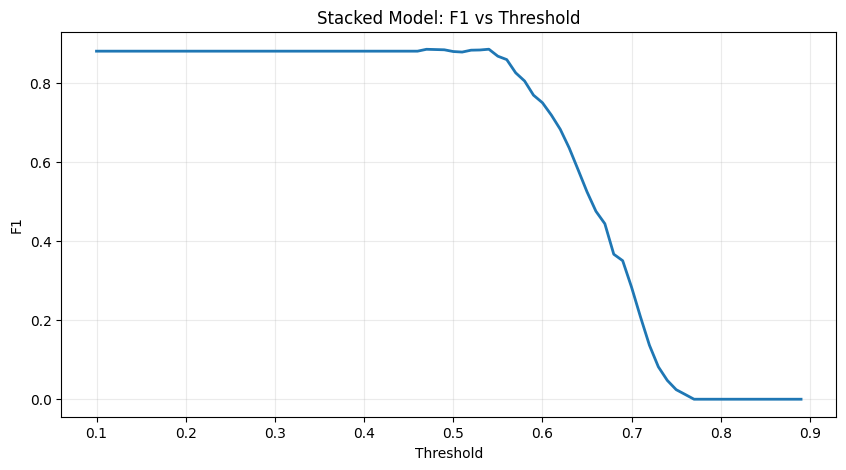

In [12]:
# threshold tuning for stacked model

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
for thresh in thresholds:
    preds_stack_labels = (preds_stack >= thresh).astype(int)
    f1_scores.append(f1_score(y_val, preds_stack_labels))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color="tab:blue", lw=2)
plt.title("Stacked Model: F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.grid(alpha=0.25)
plt.show()

In [13]:
# clf metrics

best_threshold_idx: int = int(np.argmax(f1_scores))
best_threshold: float = float(thresholds[best_threshold_idx])
best_f1: float = float(f1_scores[best_threshold_idx])

preds_stack_labels = (preds_stack >= best_threshold).astype(int)
print(f"Best threshold for stack by F1: {best_threshold:.2f} | F1={best_f1:.4f}")
print("Classification Report (Stacked Model):")
print(classification_report(y_val, preds_stack_labels))
print("Confusion Matrix (Stacked Model):")
print(confusion_matrix(y_val, preds_stack_labels))


Best threshold for stack by F1: 0.54 | F1=0.8843
Classification Report (Stacked Model):
              precision    recall  f1-score   support

           0       0.58      0.47      0.52        45
           1       0.86      0.91      0.88       164

    accuracy                           0.81       209
   macro avg       0.72      0.69      0.70       209
weighted avg       0.80      0.81      0.81       209

Confusion Matrix (Stacked Model):
[[ 21  24]
 [ 15 149]]


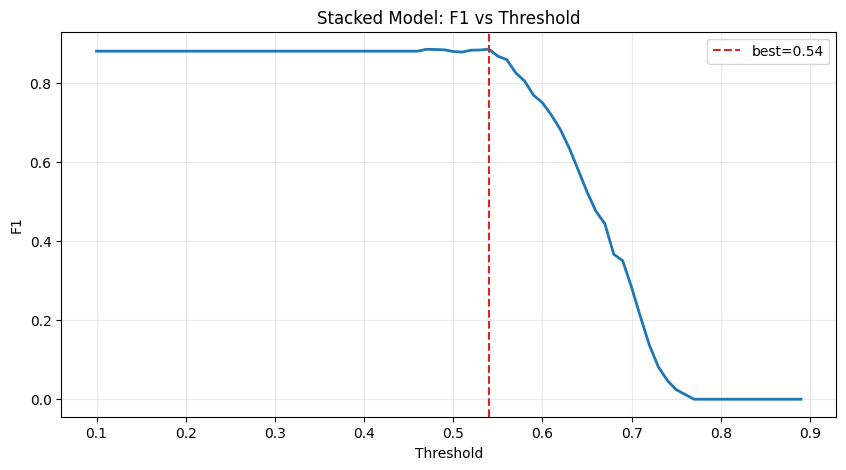

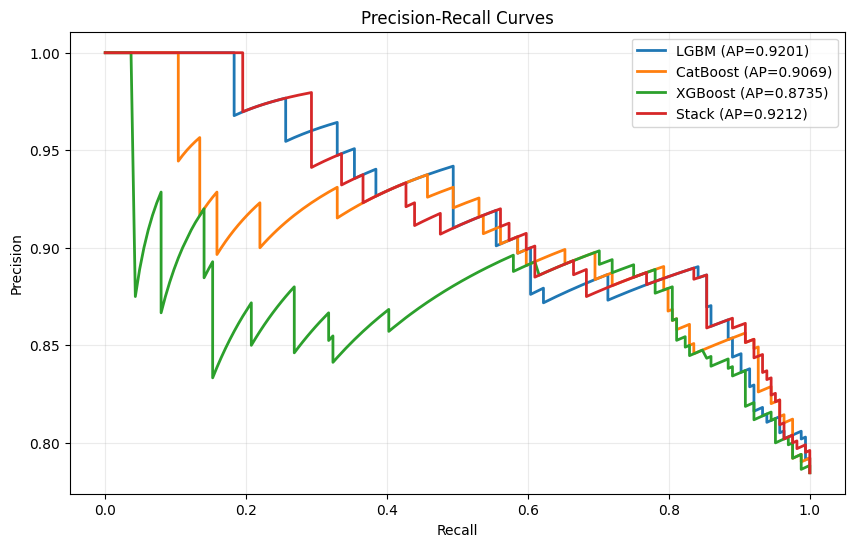

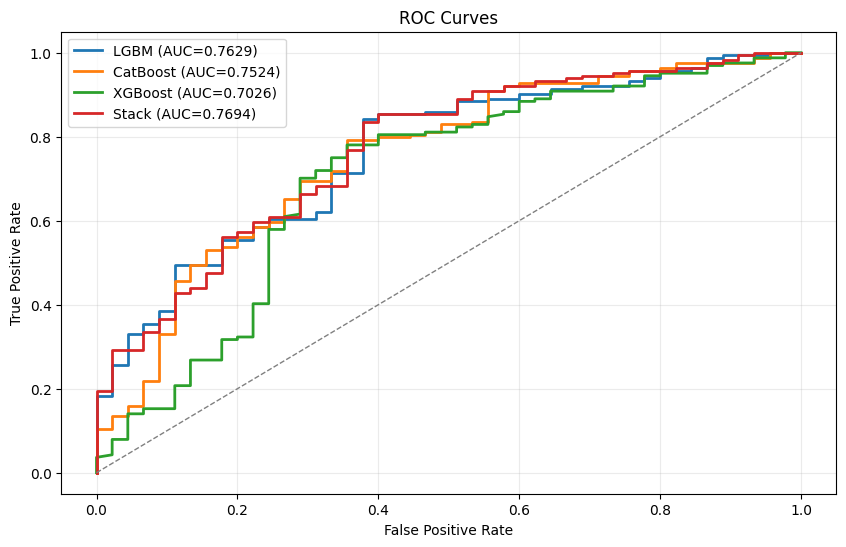

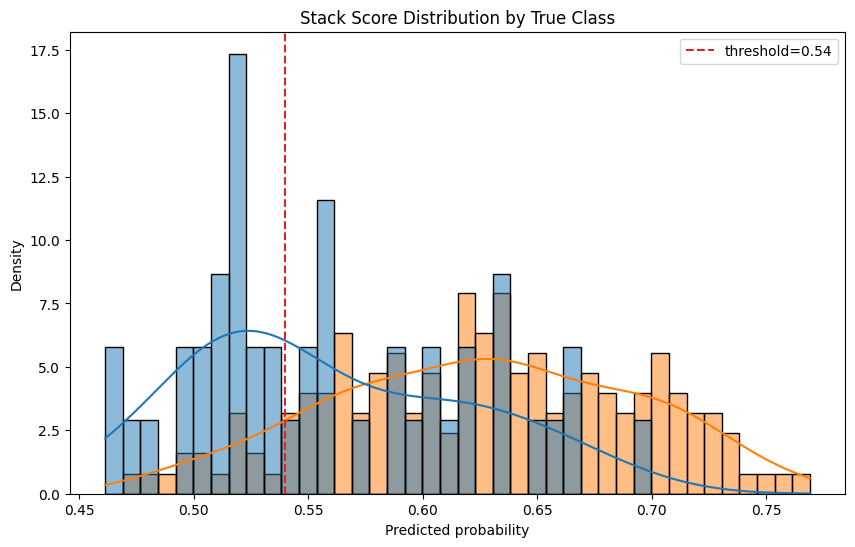

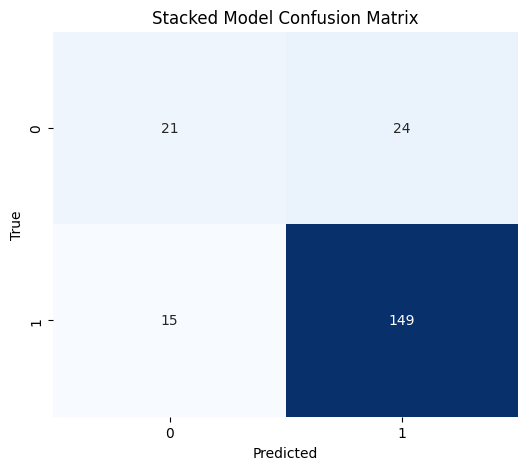

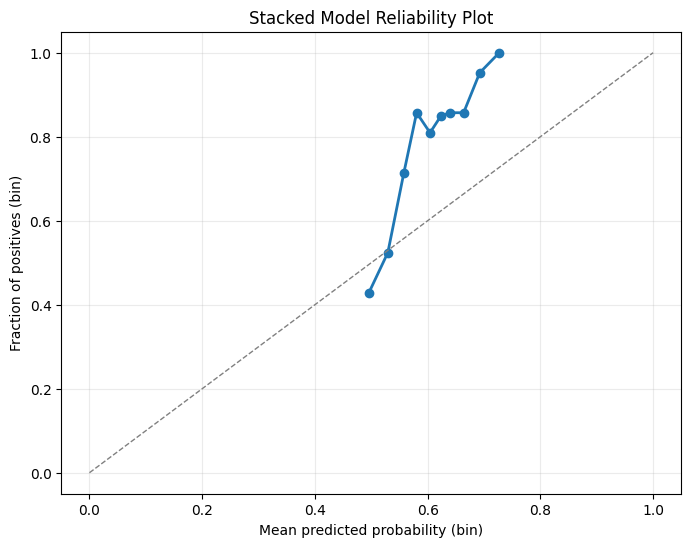

In [18]:
# informative plots

from sklearn.metrics import precision_recall_curve, roc_curve, auc

# 1) F1 vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color="tab:blue", lw=2)
plt.axvline(best_threshold, color="tab:red", linestyle="--", label=f"best={best_threshold:.2f}")
plt.title("Stacked Model: F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 2) Precision-Recall curves
models_preds = {
    "LGBM": preds_lgbm,
    "CatBoost": preds_catboost,
    "XGBoost": preds_xgboost,
    "Stack": preds_stack,
}

plt.figure(figsize=(10, 6))
for model_name, model_preds in models_preds.items():
    precision, recall, _ = precision_recall_curve(y_val, model_preds)
    ap_value = average_precision_score(y_val, model_preds)
    plt.plot(recall, precision, lw=2, label=f"{model_name} (AP={ap_value:.4f})")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 3) ROC curves
plt.figure(figsize=(10, 6))
for model_name, model_preds in models_preds.items():
    fpr, tpr, _ = roc_curve(y_val, model_preds)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 4) Distribution of stacked probabilities by true class
plot_df = pd.DataFrame({"y_true": y_val.values, "stack_score": preds_stack})
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x="stack_score", hue="y_true", bins=40, kde=True, stat="density", common_norm=False)
plt.axvline(best_threshold, color="tab:red", linestyle="--", label=f"threshold={best_threshold:.2f}")
plt.title("Stack Score Distribution by True Class")
plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.legend()
plt.show()

# 5) Confusion matrix heatmap for stacked model
cm = confusion_matrix(y_val, preds_stack_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Stacked Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 6) Calibration-style reliability plot (deciles)
calib_df = pd.DataFrame({"y_true": y_val.values, "score": preds_stack})
calib_df["bin"] = pd.qcut(calib_df["score"], q=10, duplicates="drop")
calib_curve = calib_df.groupby("bin", observed=False).agg(mean_score=("score", "mean"), frac_pos=("y_true", "mean"))

plt.figure(figsize=(8, 6))
plt.plot(calib_curve["mean_score"], calib_curve["frac_pos"], marker="o", lw=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
plt.title("Stacked Model Reliability Plot")
plt.xlabel("Mean predicted probability (bin)")
plt.ylabel("Fraction of positives (bin)")
plt.grid(alpha=0.25)
plt.show()

[0]	validation_0-logloss:1.16811
[1]	validation_0-logloss:1.16787
[2]	validation_0-logloss:1.16557
[3]	validation_0-logloss:1.16198
[4]	validation_0-logloss:1.15766
[5]	validation_0-logloss:1.15635
[6]	validation_0-logloss:1.15467
[7]	validation_0-logloss:1.15197
[8]	validation_0-logloss:1.15087
[9]	validation_0-logloss:1.14795
[10]	validation_0-logloss:1.14646
[11]	validation_0-logloss:1.14642
[12]	validation_0-logloss:1.14550
[13]	validation_0-logloss:1.14568
[14]	validation_0-logloss:1.14263
[15]	validation_0-logloss:1.14155
[16]	validation_0-logloss:1.13914
[17]	validation_0-logloss:1.13792
[18]	validation_0-logloss:1.13699
[19]	validation_0-logloss:1.13757
[20]	validation_0-logloss:1.13615
[21]	validation_0-logloss:1.13607
[22]	validation_0-logloss:1.13346
[23]	validation_0-logloss:1.13264
[24]	validation_0-logloss:1.13240
[25]	validation_0-logloss:1.12995
[26]	validation_0-logloss:1.12863
[27]	validation_0-logloss:1.12718
[28]	validation_0-logloss:1.12472
[29]	validation_0-loglos

C:\Users\User\AppData\Local\Temp\ipykernel_7380\1083448046.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_lgbm.head(20), x="importance", y="feature", palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_7380\1083448046.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_catboost.head(20), x="importance", y="feature", palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_7380\1083448046.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_xgboost.head(20), x="importance", y="fe

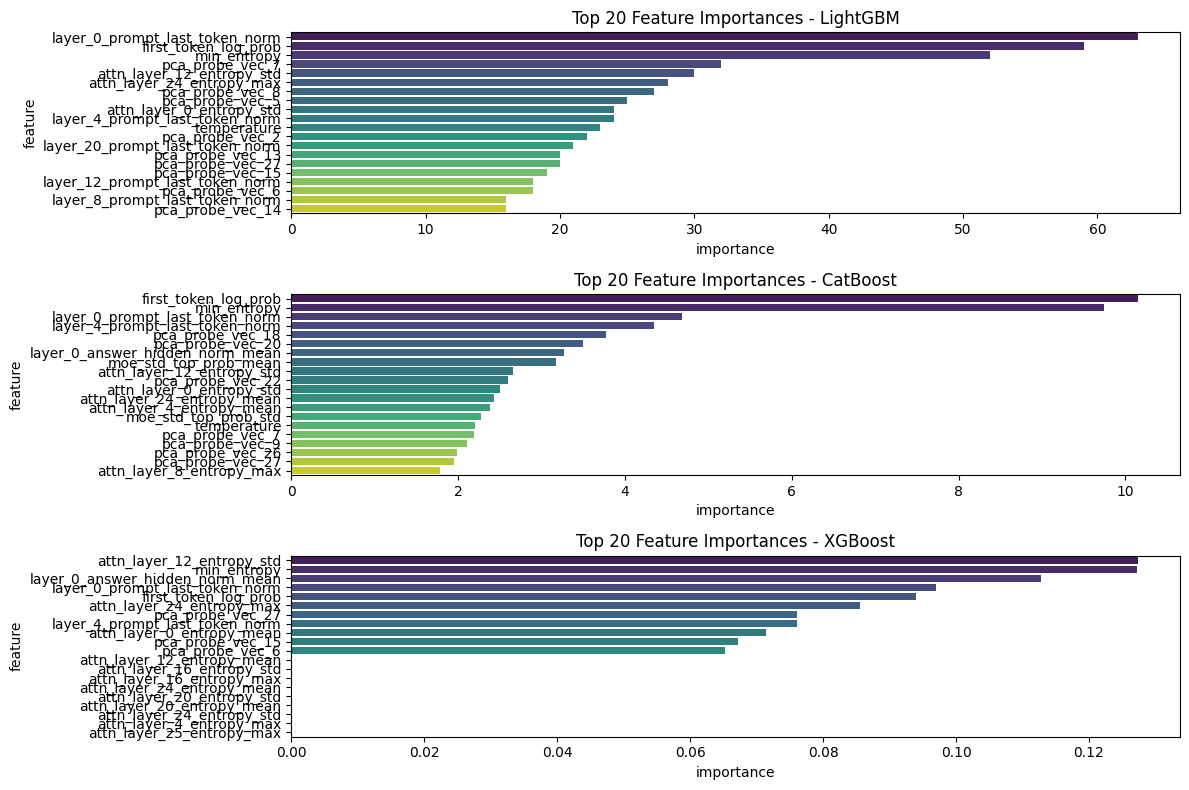

In [15]:
# feature importance

# lgbm
model_lgbm_final = lgb.LGBMClassifier(**best_lgbm_params)
model_lgbm_final.fit(X_train, y_train)
importances_lgbm = model_lgbm_final.feature_importances_
feat_imp_lgbm = pd.DataFrame({"feature": X_train.columns, "importance": importances_lgbm}).sort_values("importance", ascending=False)

# catboost
model_catboost_final = cb.CatBoostClassifier(**best_catboost_params)
model_catboost_final.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
importances_catboost = model_catboost_final.get_feature_importance()
feat_imp_catboost = pd.DataFrame({"feature": X_train.columns, "importance": importances_catboost}).sort_values("importance", ascending=False)

# xgboost
model_xgboost_final = xgb.XGBClassifier(**best_xgboost_params)
model_xgboost_final.fit(X_train, y_train, eval_set=[(X_val, y_val)])
importances_xgboost = model_xgboost_final.feature_importances_
feat_imp_xgboost = pd.DataFrame({"feature": X_train.columns, "importance": importances_xgboost}).sort_values("importance", ascending=False)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
sns.barplot(data=feat_imp_lgbm.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importances - LightGBM")
plt.subplot(3, 1, 2)
sns.barplot(data=feat_imp_catboost.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importances - CatBoost")
plt.subplot(3, 1, 3)
sns.barplot(data=feat_imp_xgboost.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()